
# CV bias versus posterior-median PE bias for `inj_id = 2`



In [1]:

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)



## 1. File paths and configuration

The notebook first checks the original uploaded-file paths. Alternative local and cluster paths are also provided so the notebook can be moved without rewriting its analysis.


In [2]:

INJ_ID = 2

CV_PATH_CANDIDATES = [
    Path("/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6_extra/run_data/bias_syst_recovery/cv_bias_sigma_fti_all_params_all_inj_ids.csv"
    ),
]

MEDIAN_PE_PATH_CANDIDATES = [
    Path("/pbs/home/a/amahdi/PE_for_my_work/config_files/M1e6_SEOBv5_id_2/normalized_bias_corner_plots/tables/median_bias_over_sigma_PE.csv"
    ),
]

OUTPUT_DIR = Path(f"cv_vs_median_pe_comparison_inj_id_{INJ_ID}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def resolve_path(candidates, label):
    for candidate in candidates:
        if candidate.exists():
            print(f"{label}: {candidate.resolve()}")
            return candidate

    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        f"Could not find {label}. The following paths were checked:\n{checked}"
    )

CV_PATH = resolve_path(CV_PATH_CANDIDATES, "CV-bias table")
MEDIAN_PE_PATH = resolve_path(
    MEDIAN_PE_PATH_CANDIDATES,
    "posterior-median PE-bias table",
)

print(f"Output directory: {OUTPUT_DIR.resolve()}")


CV-bias table: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6_extra/run_data/bias_syst_recovery/cv_bias_sigma_fti_all_params_all_inj_ids.csv
posterior-median PE-bias table: /pbs/home/a/amahdi/PE_for_my_work/config_files/M1e6_SEOBv5_id_2/normalized_bias_corner_plots/tables/median_bias_over_sigma_PE.csv
Output directory: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2



## 2. Load and validate the input tables


In [3]:

cv_all = pd.read_csv(CV_PATH)
median_pe = pd.read_csv(MEDIAN_PE_PATH)

required_cv_columns = {
    "inj_id",
    "d_omega",
    "d_tau",
    "fti_case",
    "fti_value",
    "parameter",
    "Delta_theta_over_sigma",
    "Delta_theta",
    "sigma",
    "is_active_fti_parameter",
}

required_median_columns = {
    "active_fti_run",
    "parameter",
    "posterior_source",
    "true_value",
    "posterior_median",
    "median_minus_true",
    "sigma_method",
    "sigma_PE",
    "median_bias_over_sigma_PE",
}

missing_cv = required_cv_columns.difference(cv_all.columns)
missing_median = required_median_columns.difference(median_pe.columns)

if missing_cv:
    raise ValueError(f"Missing CV columns: {sorted(missing_cv)}")

if missing_median:
    raise ValueError(
        f"Missing posterior-median PE columns: {sorted(missing_median)}"
    )

print(f"Complete CV table:          {cv_all.shape[0]} rows")
print(f"Posterior-median PE table:  {median_pe.shape[0]} rows")
print(
    "Available CV injection IDs:",
    sorted(cv_all["inj_id"].dropna().unique()),
)


Complete CV table:          1008 rows
Posterior-median PE table:  144 rows
Available CV injection IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]



## 3. Filter the CV results to `inj_id = 2` and match corresponding cases

The matching keys are:

- `fti_case` in the CV table versus `active_fti_run` in the PE table;
- `parameter` in both tables.


In [4]:

cv = cv_all.loc[cv_all["inj_id"] == INJ_ID].copy()

if cv.empty:
    raise ValueError(f"No CV rows were found for inj_id = {INJ_ID}.")

cv_key = ["fti_case", "parameter"]
median_key = ["active_fti_run", "parameter"]

if cv.duplicated(cv_key).any():
    display(cv.loc[cv.duplicated(cv_key, keep=False)].sort_values(cv_key))
    raise ValueError("Duplicate CV matching keys were found.")

if median_pe.duplicated(median_key).any():
    display(
        median_pe.loc[
            median_pe.duplicated(median_key, keep=False)
        ].sort_values(median_key)
    )
    raise ValueError("Duplicate PE matching keys were found.")

cv_for_merge = cv[
    [
        "inj_id",
        "d_omega",
        "d_tau",
        "fti_case",
        "fti_value",
        "parameter",
        "Delta_theta_over_sigma",
        "Delta_theta",
        "sigma",
        "is_active_fti_parameter",
    ]
].rename(
    columns={
        "fti_case": "active_fti_run",
        "Delta_theta_over_sigma": "CV_bias_over_sigma",
        "Delta_theta": "CV_delta_theta",
        "sigma": "sigma_CV",
    }
)

median_for_merge = median_pe[
    [
        "active_fti_run",
        "parameter",
        "posterior_source",
        "true_value",
        "posterior_median",
        "median_minus_true",
        "sigma_method",
        "sigma_PE",
        "median_bias_over_sigma_PE",
    ]
].rename(
    columns={
        "median_minus_true": "median_PE_delta_theta",
        "median_bias_over_sigma_PE": "median_PE_bias_over_sigma",
    }
)

comparison = cv_for_merge.merge(
    median_for_merge,
    on=["active_fti_run", "parameter"],
    how="outer",
    validate="one_to_one",
    indicator=True,
)

unmatched = comparison.loc[comparison["_merge"] != "both"]

if not unmatched.empty:
    display(unmatched)
    raise ValueError(
        "Some CV and PE rows could not be matched by FTI run and parameter."
    )

comparison = comparison.drop(columns="_merge")

comparison["median_PE_minus_CV"] = (
    comparison["median_PE_bias_over_sigma"]
    - comparison["CV_bias_over_sigma"]
)
comparison["absolute_difference"] = comparison[
    "median_PE_minus_CV"
].abs()

comparison["absolute_CV_bias_over_sigma"] = comparison[
    "CV_bias_over_sigma"
].abs()
comparison["absolute_median_PE_bias_over_sigma"] = comparison[
    "median_PE_bias_over_sigma"
].abs()

comparison["raw_shift_difference"] = (
    comparison["median_PE_delta_theta"]
    - comparison["CV_delta_theta"]
)
comparison["sigma_PE_over_sigma_CV"] = (
    comparison["sigma_PE"] / comparison["sigma_CV"]
)

comparison["same_sign"] = (
    np.sign(comparison["CV_bias_over_sigma"])
    == np.sign(comparison["median_PE_bias_over_sigma"])
)

run_order = list(
    dict.fromkeys(median_pe["active_fti_run"].tolist())
)

physical_parameter_order = [
    "Mchirp",
    "q",
    "chiPN",
    "chim",
    "Deltat",
    "dist",
    "inc",
    "phi",
    "lambda",
    "beta",
    "psi",
]

run_rank = {run: index for index, run in enumerate(run_order)}

def parameter_rank(row):
    parameter = row["parameter"]
    run = row["active_fti_run"]

    if parameter in physical_parameter_order:
        return physical_parameter_order.index(parameter)

    if parameter == run:
        return len(physical_parameter_order)

    return len(physical_parameter_order) + 1

comparison["_run_rank"] = comparison["active_fti_run"].map(run_rank)
comparison["_parameter_rank"] = comparison.apply(parameter_rank, axis=1)

comparison = (
    comparison.sort_values(
        ["_run_rank", "_parameter_rank", "parameter"]
    )
    .drop(columns=["_run_rank", "_parameter_rank"])
    .reset_index(drop=True)
)

print(f"CV rows retained for inj_id={INJ_ID}: {len(cv)}")
print(f"Matched rows:                       {len(comparison)}")
print(
    f"Matched FTI recovery runs:          "
    f"{comparison['active_fti_run'].nunique()}"
)
print(
    "Rows in each recovery run:",
    comparison.groupby("active_fti_run").size().unique(),
)

display(
    comparison[
        [
            "active_fti_run",
            "parameter",
            "CV_bias_over_sigma",
            "median_PE_bias_over_sigma",
            "median_PE_minus_CV",
            "sigma_CV",
            "sigma_PE",
            "is_active_fti_parameter",
        ]
    ].head(24)
)


CV rows retained for inj_id=2: 144
Matched rows:                       144
Matched FTI recovery runs:          12
Rows in each recovery run: [12]


,active_fti_run,parameter,CV_bias_over_sigma,median_PE_bias_over_sigma,median_PE_minus_CV,sigma_CV,sigma_PE,is_active_fti_parameter
0,fti_dchi0v,Mchirp,-0.058532,-0.060490,-0.001958,90.017812,92.470229,False
1,fti_dchi0v,q,-1.488823,-1.477454,0.011369,0.004671,0.004598,False
2,fti_dchi0v,chiPN,-1.190669,-1.214685,-0.024017,0.000303,0.000299,False
3,fti_dchi0v,chim,-0.347987,-0.320788,0.027200,0.002629,0.002626,False
4,fti_dchi0v,Deltat,0.550242,0.633029,0.082787,0.095489,0.096339,False
5,fti_dchi0v,dist,-0.432309,-0.420359,0.011949,28.145674,28.711417,False
6,fti_dchi0v,inc,0.468518,0.479366,0.010848,0.002854,0.002842,False
7,fti_dchi0v,phi,-1.380767,-1.381843,-0.001076,0.015802,0.015646,False
8,fti_dchi0v,lambda,-0.431703,-0.446519,-0.014816,0.003394,0.003394,False
9,fti_dchi0v,beta,-0.088690,-0.091195,-0.002505,0.001705,0.001710,False



## 4. Save the complete matched comparison table


In [5]:

comparison_path = (
    OUTPUT_DIR
    / f"cv_vs_median_pe_bias_over_sigma_inj_id_{INJ_ID}.csv"
)
comparison.to_csv(comparison_path, index=False)

print(f"Saved: {comparison_path.resolve()}")


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/cv_vs_median_pe_bias_over_sigma_inj_id_2.csv



## 5. Side-by-side comparison for the active FTI parameter

This section selects the active FTI parameter from each of the 12 recovery runs and places the CV and posterior-median PE biases side by side.


In [6]:

active_fti = comparison.loc[
    comparison["is_active_fti_parameter"].astype(bool)
].copy()

incorrect_active_rows = active_fti.loc[
    active_fti["parameter"] != active_fti["active_fti_run"]
]

if not incorrect_active_rows.empty:
    display(incorrect_active_rows)
    raise ValueError(
        "A row marked as the active FTI parameter does not match "
        "the corresponding FTI run name."
    )

active_fti_columns = [
    "active_fti_run",
    "parameter",
    "CV_bias_over_sigma",
    "median_PE_bias_over_sigma",
    "median_PE_minus_CV",
    "absolute_difference",
    "CV_delta_theta",
    "median_PE_delta_theta",
    "sigma_CV",
    "sigma_PE",
    "sigma_PE_over_sigma_CV",
    "same_sign",
]

active_fti_table = active_fti[
    active_fti_columns
].reset_index(drop=True)

active_fti_path = (
    OUTPUT_DIR
    / f"active_fti_cv_vs_median_pe_inj_id_{INJ_ID}.csv"
)
active_fti_table.to_csv(active_fti_path, index=False)

display(active_fti_table)
print(f"Saved: {active_fti_path.resolve()}")


,active_fti_run,parameter,CV_bias_over_sigma,median_PE_bias_over_sigma,median_PE_minus_CV,absolute_difference,CV_delta_theta,median_PE_delta_theta,sigma_CV,sigma_PE,sigma_PE_over_sigma_CV,same_sign
0,fti_dchi0v,fti_dchi0v,0.034062,0.040439,0.006377,0.006377,1.563744e-05,1.907857e-05,0.000459,0.000472,1.027654,True
1,fti_dchi1v,fti_dchi1v,-0.040000,-0.106117,-0.066117,0.066117,-2.739501e-05,-7.269117e-05,0.000685,0.000685,1.000195,True
2,fti_dchi2v,fti_dchi2v,-0.011138,-0.027819,-0.016681,0.016681,-5.133796e-06,-1.260397e-05,0.000461,0.000453,0.982954,True
3,fti_dchi3v,fti_dchi3v,-0.031590,0.009540,0.041130,0.041130,-1.373103e-05,4.158158e-06,0.000435,0.000436,1.002770,False
4,fti_dchi4v,fti_dchi4v,0.078426,0.052584,-0.025841,0.025841,3.168883e-04,2.072702e-04,0.004041,0.003942,0.975515,True
5,fti_dchi5lv,fti_dchi5lv,-0.121964,-0.100464,0.021499,0.021499,-8.929027e-04,-7.387190e-04,0.007321,0.007353,1.004368,True
6,fti_dchi6lv,fti_dchi6lv,-0.095260,-0.109386,-0.014126,0.014126,-9.626026e-04,-1.113836e-03,0.010105,0.010183,1.007680,True
7,fti_dchi6v,fti_dchi6v,-0.157717,-0.152336,0.005381,0.005381,-9.899643e-04,-9.521237e-04,0.006277,0.006250,0.995752,True
8,fti_dchi7v,fti_dchi7v,0.184696,0.172790,-0.011906,0.011906,4.987173e-04,4.680315e-04,0.002700,0.002709,1.003136,True
9,fti_dchiMinus2v,fti_dchiMinus2v,0.124790,0.127598,0.002807,0.002807,1.376918e-07,1.452461e-07,0.000001,0.000001,1.031656,True


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/active_fti_cv_vs_median_pe_inj_id_2.csv


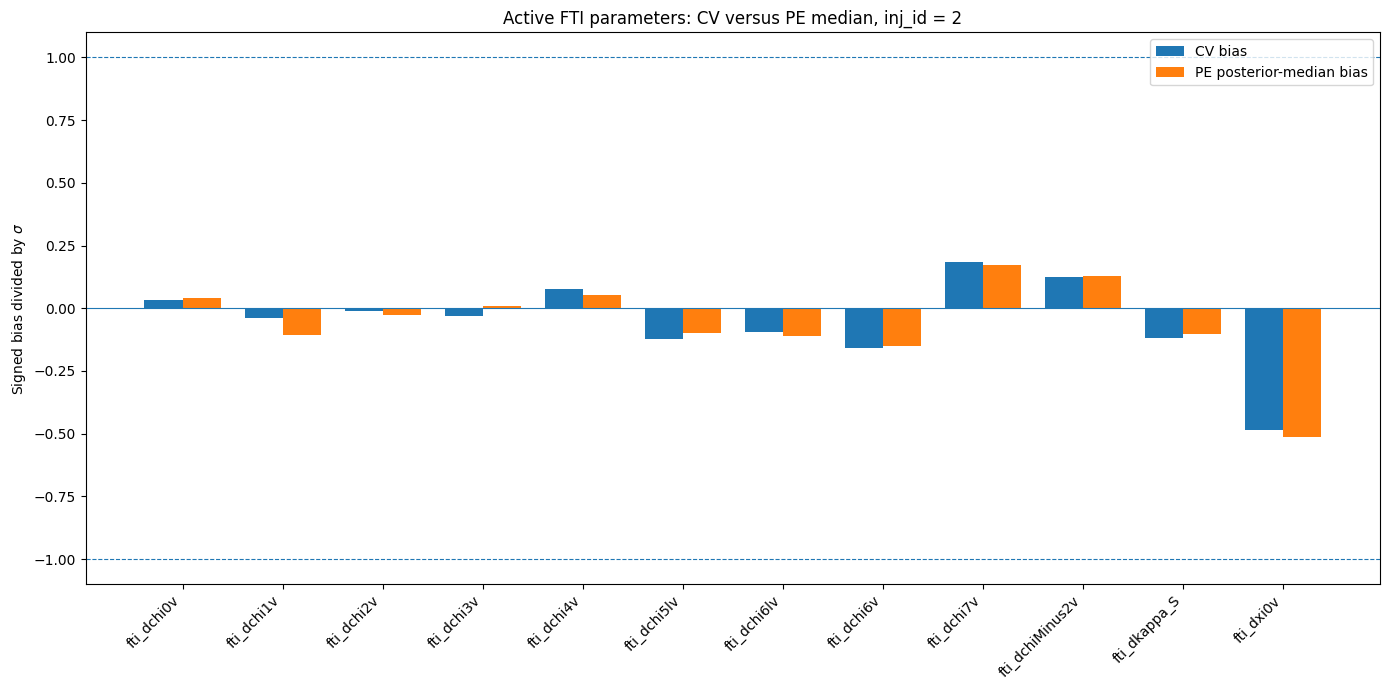

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/active_fti_cv_vs_median_pe_inj_id_2.png


In [7]:

positions = np.arange(len(active_fti_table))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    positions - bar_width / 2,
    active_fti_table["CV_bias_over_sigma"],
    width=bar_width,
    label="CV bias",
)

ax.bar(
    positions + bar_width / 2,
    active_fti_table["median_PE_bias_over_sigma"],
    width=bar_width,
    label="PE posterior-median bias",
)

ax.axhline(0, linewidth=0.8)
ax.axhline(1, linestyle="--", linewidth=0.8)
ax.axhline(-1, linestyle="--", linewidth=0.8)

ax.set_xticks(positions)
ax.set_xticklabels(
    active_fti_table["active_fti_run"],
    rotation=45,
    ha="right",
)

ax.set_ylabel(r"Signed bias divided by $\sigma$")
ax.set_title(
    f"Active FTI parameters: CV versus PE median, inj_id = {INJ_ID}"
)
ax.legend()

fig.tight_layout()

active_plot_path = (
    OUTPUT_DIR
    / f"active_fti_cv_vs_median_pe_inj_id_{INJ_ID}.png"
)
fig.savefig(active_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {active_plot_path.resolve()}")



## 6. Detailed side-by-side plots for every corresponding FTI case

Each panel contains all physical parameters and the active FTI parameter for one recovery run.


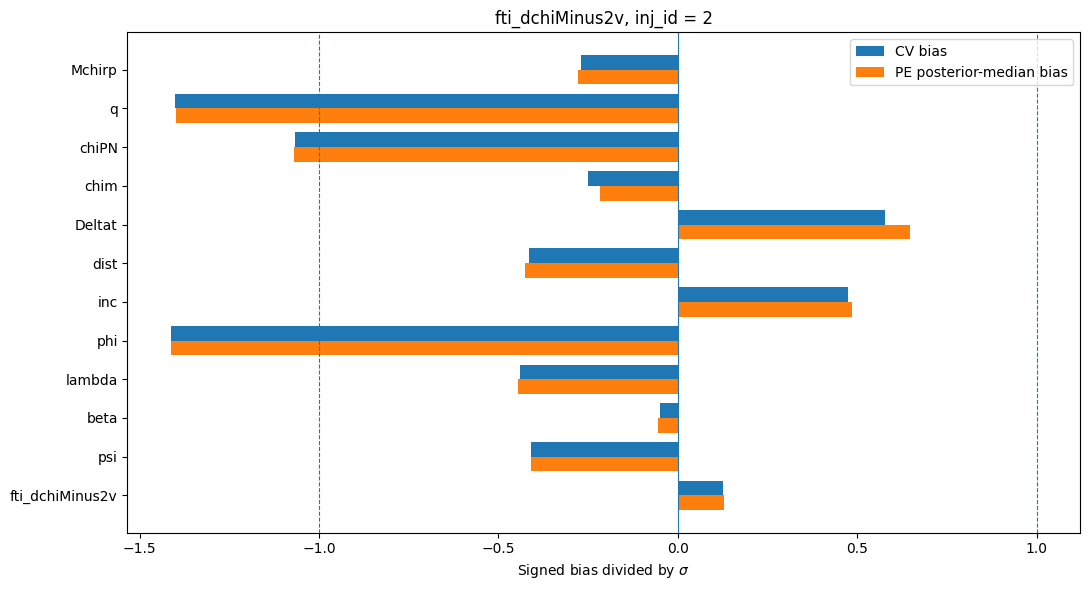

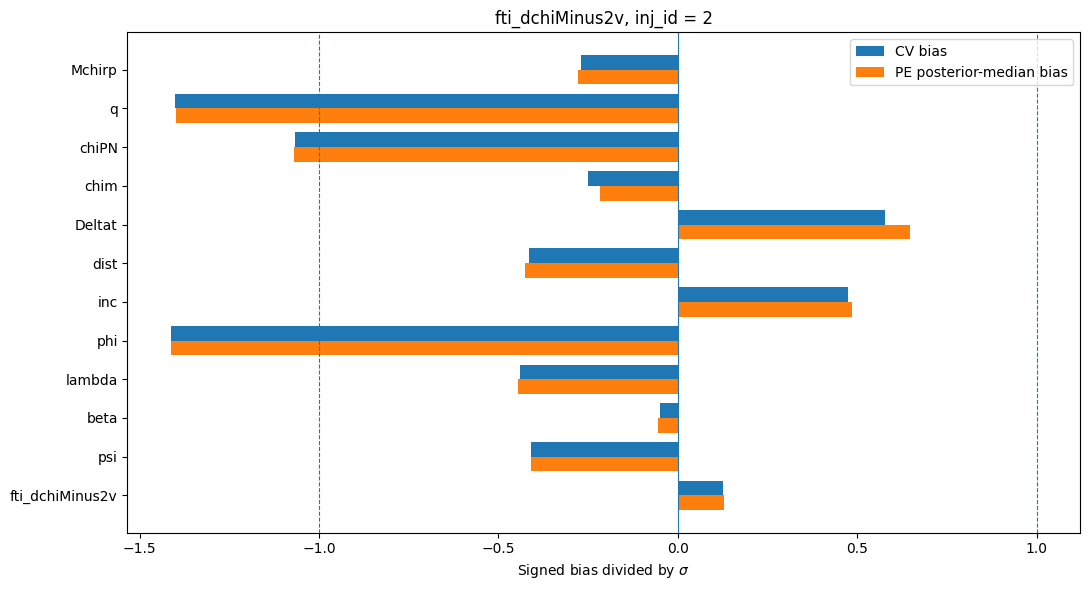

In [8]:

def make_single_run_plot(run_name, save=True, show=True):
    group = comparison.loc[
        comparison["active_fti_run"] == run_name
    ].copy()

    if group.empty:
        raise ValueError(
            f"{run_name!r} is not present. "
            f"Available runs: {run_order}"
        )

    positions = np.arange(len(group))
    bar_width = 0.38
    fig_height = max(6, 0.48 * len(group))

    fig, ax = plt.subplots(figsize=(11, fig_height))

    ax.barh(
        positions - bar_width / 2,
        group["CV_bias_over_sigma"],
        height=bar_width,
        label="CV bias",
    )

    ax.barh(
        positions + bar_width / 2,
        group["median_PE_bias_over_sigma"],
        height=bar_width,
        label="PE posterior-median bias",
    )

    ax.axvline(0, linewidth=0.8)
    ax.axvline(1, linestyle="--", linewidth=0.8)
    ax.axvline(-1, linestyle="--", linewidth=0.8)

    ax.set_yticks(positions)
    ax.set_yticklabels(group["parameter"])
    ax.invert_yaxis()

    ax.set_xlabel(r"Signed bias divided by $\sigma$")
    ax.set_title(f"{run_name}, inj_id = {INJ_ID}")
    ax.legend()

    fig.tight_layout()

    if save:
        plot_path = (
            OUTPUT_DIR
            / f"{run_name}_cv_vs_median_pe_inj_id_{INJ_ID}.png"
        )
        fig.savefig(plot_path, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


SELECTED_RUN = "fti_dchiMinus2v"
make_single_run_plot(SELECTED_RUN, save=True, show=True)


In [9]:

all_runs_pdf = (
    OUTPUT_DIR
    / f"all_fti_runs_cv_vs_median_pe_inj_id_{INJ_ID}.pdf"
)

with PdfPages(all_runs_pdf) as pdf:
    for run_name in run_order:
        group = comparison.loc[
            comparison["active_fti_run"] == run_name
        ].copy()

        positions = np.arange(len(group))
        bar_width = 0.38
        fig_height = max(6, 0.48 * len(group))

        fig, ax = plt.subplots(figsize=(11, fig_height))

        ax.barh(
            positions - bar_width / 2,
            group["CV_bias_over_sigma"],
            height=bar_width,
            label="CV bias",
        )

        ax.barh(
            positions + bar_width / 2,
            group["median_PE_bias_over_sigma"],
            height=bar_width,
            label="PE posterior-median bias",
        )

        ax.axvline(0, linewidth=0.8)
        ax.axvline(1, linestyle="--", linewidth=0.8)
        ax.axvline(-1, linestyle="--", linewidth=0.8)

        ax.set_yticks(positions)
        ax.set_yticklabels(group["parameter"])
        ax.invert_yaxis()

        ax.set_xlabel(r"Signed bias divided by $\sigma$")
        ax.set_title(f"{run_name}, inj_id = {INJ_ID}")
        ax.legend()

        fig.tight_layout()

        png_path = (
            OUTPUT_DIR
            / f"{run_name}_cv_vs_median_pe_inj_id_{INJ_ID}.png"
        )
        fig.savefig(png_path, dpi=200, bbox_inches="tight")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Saved all individual plots in: {OUTPUT_DIR.resolve()}")
print(f"Saved combined PDF: {all_runs_pdf.resolve()}")


Saved all individual plots in: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2
Saved combined PDF: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/all_fti_runs_cv_vs_median_pe_inj_id_2.pdf



## 7. Direct CV-versus-median scatter plot

The dashed diagonal represents exact equality between the two normalized biases.


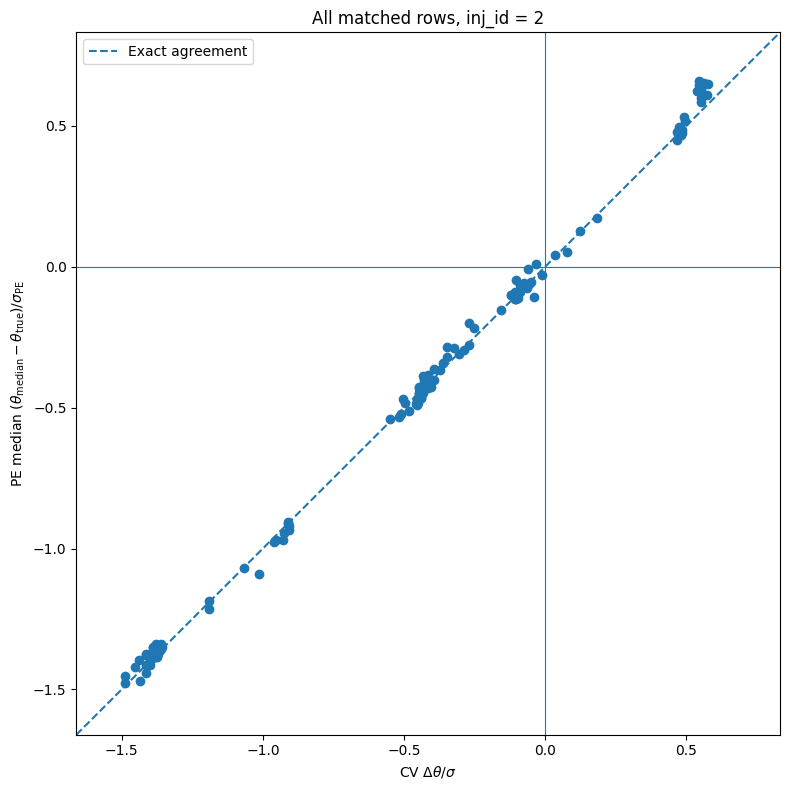

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/scatter_cv_vs_median_pe_inj_id_2.png


In [10]:

x = comparison["CV_bias_over_sigma"].to_numpy(dtype=float)
y = comparison["median_PE_bias_over_sigma"].to_numpy(dtype=float)

finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]

lower = min(x.min(), y.min())
upper = max(x.max(), y.max())
padding = 0.08 * max(upper - lower, 1.0)
limits = (lower - padding, upper + padding)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(x, y)
ax.plot(limits, limits, linestyle="--", label="Exact agreement")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(limits)
ax.set_ylim(limits)

ax.set_xlabel(r"CV $\Delta\theta/\sigma$")
ax.set_ylabel(
    r"PE median $(\theta_{\mathrm{median}}-\theta_{\mathrm{true}})"
    r"/\sigma_{\mathrm{PE}}$"
)
ax.set_title(f"All matched rows, inj_id = {INJ_ID}")
ax.legend()

fig.tight_layout()

scatter_path = (
    OUTPUT_DIR
    / f"scatter_cv_vs_median_pe_inj_id_{INJ_ID}.png"
)
fig.savefig(scatter_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {scatter_path.resolve()}")



## 8. Difference heatmap

The plotted value is

\[
\left(rac{\Delta	heta}{\sigma}ight)_{\mathrm{PE,median}}
-
\left(rac{\Delta	heta}{\sigma}ight)_{\mathrm{CV}}.
\]

A value close to zero indicates close agreement.


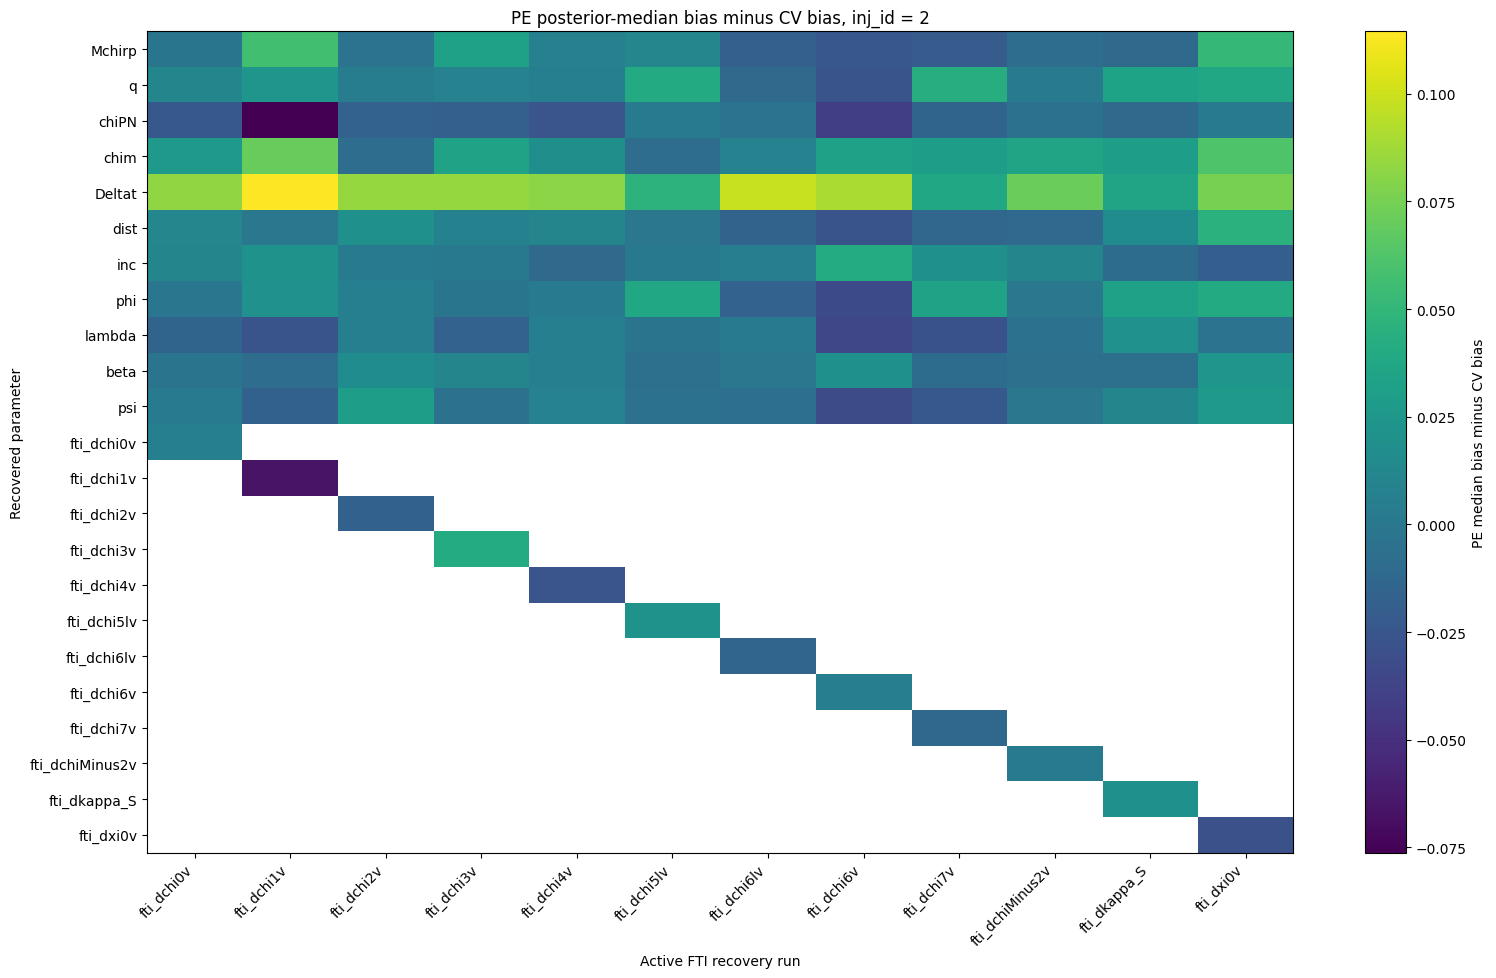

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/heatmap_median_pe_minus_cv_inj_id_2.png


In [11]:

parameter_order = physical_parameter_order + run_order

difference_matrix = comparison.pivot(
    index="parameter",
    columns="active_fti_run",
    values="median_PE_minus_CV",
).reindex(
    index=parameter_order,
    columns=run_order,
)

masked = np.ma.masked_invalid(
    difference_matrix.to_numpy(dtype=float)
)

fig_height = max(8, 0.43 * len(difference_matrix.index))
fig, ax = plt.subplots(figsize=(16, fig_height))

image = ax.imshow(masked, aspect="auto")

ax.set_xticks(np.arange(len(difference_matrix.columns)))
ax.set_xticklabels(
    difference_matrix.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(np.arange(len(difference_matrix.index)))
ax.set_yticklabels(difference_matrix.index)

ax.set_xlabel("Active FTI recovery run")
ax.set_ylabel("Recovered parameter")
ax.set_title(
    f"PE posterior-median bias minus CV bias, inj_id = {INJ_ID}"
)

fig.colorbar(
    image,
    ax=ax,
    label="PE median bias minus CV bias",
)

fig.tight_layout()

heatmap_path = (
    OUTPUT_DIR
    / f"heatmap_median_pe_minus_cv_inj_id_{INJ_ID}.png"
)
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {heatmap_path.resolve()}")



## 9. Agreement statistics for each corresponding FTI case


In [12]:

def safe_pearson(group):
    x = group["CV_bias_over_sigma"].to_numpy(dtype=float)
    y = group["median_PE_bias_over_sigma"].to_numpy(dtype=float)

    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return np.corrcoef(x, y)[0, 1]


summary_rows = []

for run_name, group in comparison.groupby(
    "active_fti_run",
    sort=False,
):
    difference = group["median_PE_minus_CV"].to_numpy(dtype=float)
    largest_index = group["absolute_difference"].idxmax()
    largest_row = group.loc[largest_index]

    summary_rows.append(
        {
            "active_fti_run": run_name,
            "n_parameters": len(group),
            "mean_absolute_difference": np.mean(np.abs(difference)),
            "RMSE": np.sqrt(np.mean(difference**2)),
            "Pearson_correlation": safe_pearson(group),
            "sign_agreement_fraction": group["same_sign"].mean(),
            "maximum_absolute_difference": largest_row[
                "absolute_difference"
            ],
            "parameter_with_maximum_difference": largest_row[
                "parameter"
            ],
        }
    )

run_summary = pd.DataFrame(summary_rows)

run_summary_path = (
    OUTPUT_DIR
    / f"summary_by_fti_run_cv_vs_median_pe_inj_id_{INJ_ID}.csv"
)
run_summary.to_csv(run_summary_path, index=False)

display(run_summary)
print(f"Saved: {run_summary_path.resolve()}")


,active_fti_run,n_parameters,mean_absolute_difference,RMSE,Pearson_correlation,sign_agreement_fraction,maximum_absolute_difference,parameter_with_maximum_difference
0,fti_dchi0v,12,0.016510,0.027144,0.999421,1.000000,0.082787,Deltat
1,fti_dchi1v,12,0.041807,0.053186,0.996820,1.000000,0.114480,Deltat
2,fti_dchi2v,12,0.017744,0.027919,0.999211,1.000000,0.084338,Deltat
3,fti_dchi3v,12,0.021696,0.031393,0.999226,0.916667,0.084034,Deltat
4,fti_dchi4v,12,0.017340,0.026964,0.999161,1.000000,0.081146,Deltat
5,fti_dchi5lv,12,0.015481,0.022566,0.999479,1.000000,0.047428,Deltat
6,fti_dchi6lv,12,0.016551,0.030311,0.999182,1.000000,0.098695,Deltat
7,fti_dchi6v,12,0.034149,0.039258,0.999235,1.000000,0.090418,Deltat
8,fti_dchi7v,12,0.023699,0.025820,0.999166,1.000000,0.042250,q
9,fti_dchiMinus2v,12,0.013196,0.023778,0.999508,1.000000,0.071795,Deltat


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/summary_by_fti_run_cv_vs_median_pe_inj_id_2.csv



## 10. Rows with the largest disagreement


In [13]:

largest_disagreements = comparison.nlargest(
    20,
    "absolute_difference",
)[
    [
        "active_fti_run",
        "parameter",
        "CV_bias_over_sigma",
        "median_PE_bias_over_sigma",
        "median_PE_minus_CV",
        "absolute_difference",
        "CV_delta_theta",
        "median_PE_delta_theta",
        "sigma_CV",
        "sigma_PE",
        "sigma_PE_over_sigma_CV",
    ]
]

largest_path = (
    OUTPUT_DIR
    / f"largest_cv_vs_median_pe_disagreements_inj_id_{INJ_ID}.csv"
)
largest_disagreements.to_csv(largest_path, index=False)

display(largest_disagreements)
print(f"Saved: {largest_path.resolve()}")


,active_fti_run,parameter,CV_bias_over_sigma,median_PE_bias_over_sigma,median_PE_minus_CV,absolute_difference,CV_delta_theta,median_PE_delta_theta,sigma_CV,sigma_PE,sigma_PE_over_sigma_CV
16,fti_dchi1v,Deltat,0.545318,0.659798,0.114480,0.114480,0.050564,0.062167,0.092724,0.094221,1.016148
76,fti_dchi6lv,Deltat,0.546271,0.644966,0.098695,0.098695,0.056204,0.066782,0.102887,0.103544,1.006390
88,fti_dchi6v,Deltat,0.562506,0.652924,0.090418,0.090418,0.060992,0.072027,0.108428,0.110315,1.017402
28,fti_dchi2v,Deltat,0.540394,0.624732,0.084338,0.084338,0.051131,0.060147,0.094617,0.096277,1.017543
40,fti_dchi3v,Deltat,0.538280,0.622315,0.084034,0.084034,0.052668,0.060421,0.097845,0.097090,0.992292
4,fti_dchi0v,Deltat,0.550242,0.633029,0.082787,0.082787,0.052542,0.060986,0.095489,0.096339,1.008907
52,fti_dchi4v,Deltat,0.542251,0.623397,0.081146,0.081146,0.055179,0.064075,0.101759,0.102783,1.010062
14,fti_dchi1v,chiPN,-1.015453,-1.091659,-0.076207,0.076207,-0.000368,-0.000390,0.000363,0.000358,0.985763
136,fti_dxi0v,Deltat,0.550205,0.625702,0.075497,0.075497,0.052630,0.060791,0.095655,0.097156,1.015685
112,fti_dchiMinus2v,Deltat,0.575886,0.647680,0.071795,0.071795,0.051868,0.058858,0.090066,0.090875,1.008977


Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/largest_cv_vs_median_pe_disagreements_inj_id_2.csv



## Interpretation

The normalized quantities may disagree because of differences in either or both of the following:

1. the CV linearized parameter displacement and the actual posterior-median displacement;
2. the Fisher uncertainty `sigma_CV` and the PE posterior uncertainty `sigma_PE`.

The complete output table therefore retains both raw displacements and both uncertainties, rather than comparing only the final normalized ratios.


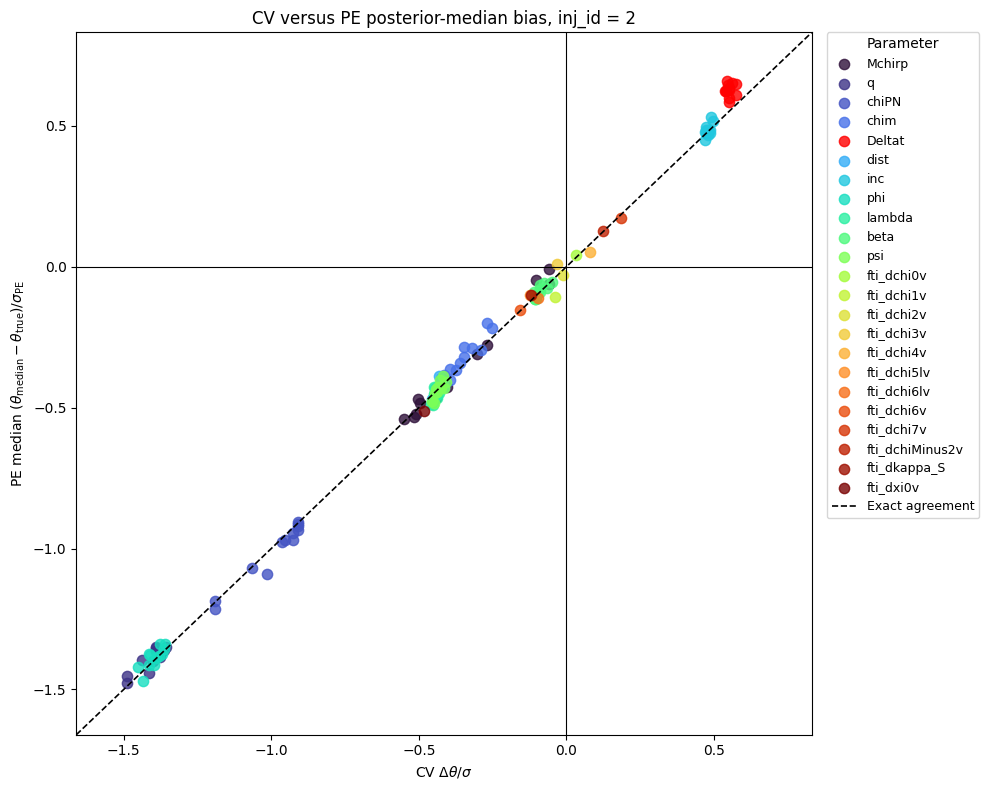

Saved: /pbs/home/a/amahdi/PE_for_my_work/Comparison/No nelder mead/cv_vs_median_pe_comparison_inj_id_2/scatter_cv_vs_median_pe_by_parameter_inj_id_2.png


In [14]:
# Keep only finite values while retaining the parameter labels
plot_data = comparison[
    [
        "CV_bias_over_sigma",
        "median_PE_bias_over_sigma",
        "parameter",
    ]
].copy()

finite = (
    np.isfinite(plot_data["CV_bias_over_sigma"])
    & np.isfinite(plot_data["median_PE_bias_over_sigma"])
)

plot_data = plot_data.loc[finite].copy()

# Unique recovered parameters
parameters = plot_data["parameter"].unique().tolist()

# Generate a different color for each parameter
cmap = plt.colormaps["turbo"].resampled(len(parameters))

parameter_colors = {
    parameter: cmap(index)
    for index, parameter in enumerate(parameters)
}

# Force all Deltat points to be red
parameter_colors["Deltat"] = "red"


# Determine common limits for both axes
lower = min(
    plot_data["CV_bias_over_sigma"].min(),
    plot_data["median_PE_bias_over_sigma"].min(),
)

upper = max(
    plot_data["CV_bias_over_sigma"].max(),
    plot_data["median_PE_bias_over_sigma"].max(),
)

padding = 0.08 * max(upper - lower, 1.0)
limits = (lower - padding, upper + padding)


# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

for parameter in parameters:
    parameter_data = plot_data.loc[
        plot_data["parameter"] == parameter
    ]

    ax.scatter(
        parameter_data["CV_bias_over_sigma"],
        parameter_data["median_PE_bias_over_sigma"],
        color=parameter_colors[parameter],
        label=parameter,
        s=55,
        alpha=0.8,
    )


# Exact-agreement diagonal
ax.plot(
    limits,
    limits,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Exact agreement",
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_xlim(limits)
ax.set_ylim(limits)

ax.set_xlabel(r"CV $\Delta\theta/\sigma$")

ax.set_ylabel(
    r"PE median "
    r"$(\theta_{\mathrm{median}}-\theta_{\mathrm{true}})"
    r"/\sigma_{\mathrm{PE}}$"
)

ax.set_title(
    f"CV versus PE posterior-median bias, inj_id = {INJ_ID}"
)

# Put the large parameter legend outside the plotting region
ax.legend(
    title="Parameter",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=9,
)

fig.tight_layout()

scatter_path = (
    OUTPUT_DIR
    / f"scatter_cv_vs_median_pe_by_parameter_inj_id_{INJ_ID}.png"
)

fig.savefig(
    scatter_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {scatter_path.resolve()}")